In [5]:
%pip install numpy pandas matplotlib requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import requests
import json

  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached charset_normalizer-3.4.7-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
Using cached requests-2.33.1-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.7-cp314-cp314-win_amd64.whl (159 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)

   -------- ------------------------------- 1/5 [idna]
   -------------------------------- ------- 4/5 [requests]
   ---------------------------------------- 5/5 [requests]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
csv_filename = 'credit_card_default.csv'
# Read the CSV file from the specified path
full_path = os.path.join(r'data', csv_filename)
df = pd.read_csv(full_path)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,Time to first delay
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,0
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,6
3,4,50000.0,2,2,1,37,0,0,0,0,...,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,6
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,6


In [11]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,Time to first delay
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200,4.290133
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062,2.557598
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000,2.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000,6.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000,6.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000,6.000000


  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached narwhals-2.19.0-py3-none-any.whl.metadata (14 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ------------- -------------------------- 3.7/11.1 MB 16.1 MB/s eta 0:00:01
   ------------------------------ --------- 8.4/11.1 MB 18.9 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 18.5 MB/s  0:00:00
Using cached narwhals-2.19.0-py3-none-any.whl (446 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached typing_extensions-4.15.0-py

  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


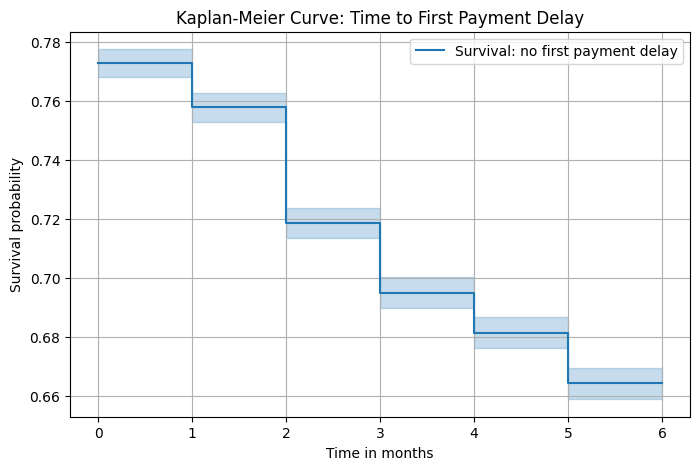

Median survival time: inf
Survival probability at 6 months: 0.6643666666666669


In [ ]:
%pip install lifelines
from lifelines import KaplanMeierFitter

time_col = "Time to first delay"
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
df["Delay_Event"] = df[pay_cols].gt(0).any(axis=1).astype(int)

kmf = KaplanMeierFitter()

kmf.fit(
    durations=df[time_col],
    event_observed=df["Delay_Event"],
    label="Survival: no first payment delay"
)

plt.figure(figsize=(8, 5))
kmf.plot_survival_function(ci_show=True)
plt.title("Kaplan-Meier Curve: Time to First Payment Delay")
plt.xlabel("Time in months")
plt.ylabel("Survival probability")
plt.grid(True)
plt.show()

median_survival_time = kmf.median_survival_time_
survival_prob_6 = kmf.predict(6)

print("Median survival time:", median_survival_time)
print("Survival probability at 6 months:", survival_prob_6)

In [13]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

time_col = "Time to first delay"
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
df["Delay_Event"] = df[pay_cols].gt(0).any(axis=1).astype(int)

df["SEX_group"] = df["SEX"].map({
    1: "Male",
    2: "Female"
})

df["EDUCATION_group"] = df["EDUCATION"].map({
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Other",
    5: "Unknown",
    6: "Unknown",
    0: "Unknown"
})

df["MARRIAGE_group"] = df["MARRIAGE"].map({
    1: "Married",
    2: "Single",
    3: "Other",
    0: "Unknown"
})

df["LIMIT_BAL_group"] = pd.qcut(
    df["LIMIT_BAL"],
    q=3,
    labels=["Low Limit", "Medium Limit", "High Limit"]
)

df["AGE_group"] = pd.cut(
    df["AGE"],
    bins=[0, 29, 39, 49, np.inf],
    labels=["<30", "30-39", "40-49", "50+"]
)

In [15]:
def km_by_group(data, group_col, title):
    kmf = KaplanMeierFitter()
    
    plt.figure(figsize=(8, 5))
    
    summary_rows = []
    
    for group in data[group_col].dropna().unique():
        group_data = data[data[group_col] == group]
        
        kmf.fit(
            durations=group_data[time_col],
            event_observed=group_data["Delay_Event"],
            label=str(group)
        )
        
        kmf.plot_survival_function(ci_show=False)
        
        summary_rows.append({
            "Variable": group_col,
            "Group": group,
            "N": len(group_data),
            "Events": group_data["Delay_Event"].sum(),
            "Event Rate": group_data["Delay_Event"].mean(),
            "Median Survival Time": kmf.median_survival_time_,
            "Survival Probability at 6 Months": kmf.predict(6)
        })
    
    plt.title(title)
    plt.xlabel("Time in months")
    plt.ylabel("Survival probability")
    plt.grid(True)
    plt.legend(title=group_col)
    plt.show()

    clean_data = data[[time_col, "Delay_Event", group_col]].dropna()
    
    logrank_result = multivariate_logrank_test(
        clean_data[time_col],
        clean_data[group_col],
        clean_data["Delay_Event"]
    )
    
    summary = pd.DataFrame(summary_rows)
    
    print(f"\nLog-rank test for {group_col}")
    print("p-value:", logrank_result.p_value)
    
    return summary

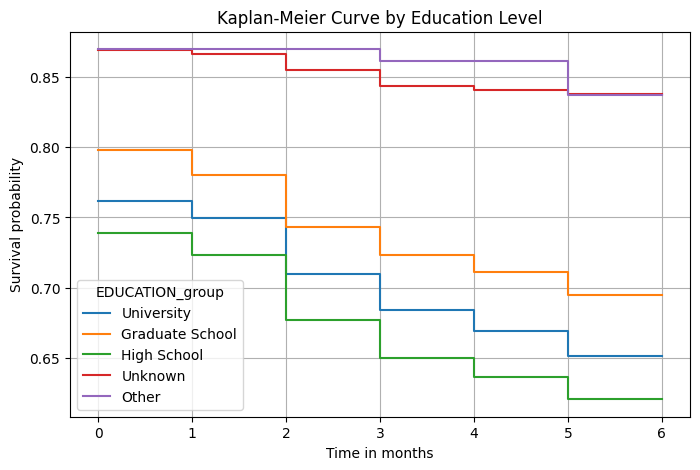


Log-rank test for EDUCATION_group
p-value: 5.8445445904353695e-33


,Variable,Group,N,Events,Event Rate,Median Survival Time,Survival Probability at 6 Months
0,EDUCATION_group,University,14030,4897,0.349038,inf,0.650962
1,EDUCATION_group,Graduate School,10585,3230,0.305149,inf,0.694851
2,EDUCATION_group,High School,4917,1866,0.379500,inf,0.620500
3,EDUCATION_group,Unknown,345,56,0.162319,inf,0.837681
4,EDUCATION_group,Other,123,20,0.162602,inf,0.837398


In [16]:
education_summary = km_by_group(
    df,
    "EDUCATION_group",
    "Kaplan-Meier Curve by Education Level"
)

education_summary

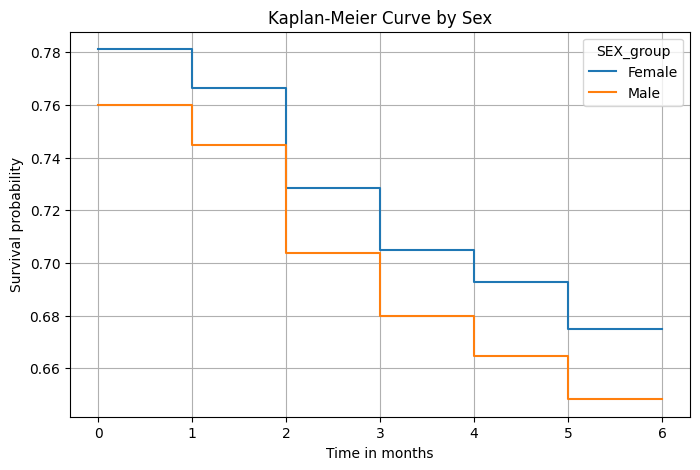


Log-rank test for SEX_group
p-value: 1.2362824494523727e-06


,Variable,Group,N,Events,Event Rate,Median Survival Time,Survival Probability at 6 Months
0,SEX_group,Female,18112,5887,0.325033,inf,0.674967
1,SEX_group,Male,11888,4182,0.351783,inf,0.648217


In [17]:
sex_summary = km_by_group(
    df,
    "SEX_group",
    "Kaplan-Meier Curve by Sex"
)

sex_summary

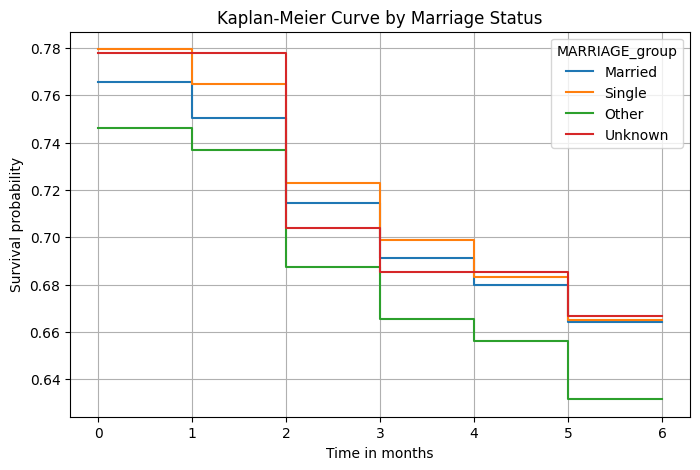


Log-rank test for MARRIAGE_group
p-value: 0.6213943598749321


,Variable,Group,N,Events,Event Rate,Median Survival Time,Survival Probability at 6 Months
0,MARRIAGE_group,Married,13659,4588,0.335896,inf,0.664104
1,MARRIAGE_group,Single,15964,5344,0.334753,inf,0.665247
2,MARRIAGE_group,Other,323,119,0.368421,inf,0.631579
3,MARRIAGE_group,Unknown,54,18,0.333333,inf,0.666667


In [18]:
marriage_summary = km_by_group(
    df,
    "MARRIAGE_group",
    "Kaplan-Meier Curve by Marriage Status"
)

marriage_summary

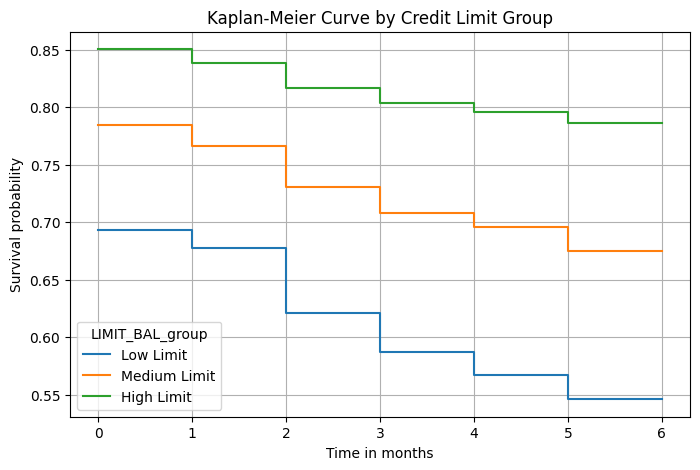


Log-rank test for LIMIT_BAL_group
p-value: 4.5601302231974715e-287


,Variable,Group,N,Events,Event Rate,Median Survival Time,Survival Probability at 6 Months
0,LIMIT_BAL_group,Low Limit,10799,4901,0.453838,inf,0.546162
1,LIMIT_BAL_group,Medium Limit,9579,3111,0.324773,inf,0.675227
2,LIMIT_BAL_group,High Limit,9622,2057,0.213781,inf,0.786219


In [19]:
limit_summary = km_by_group(
    df,
    "LIMIT_BAL_group",
    "Kaplan-Meier Curve by Credit Limit Group"
)

limit_summary

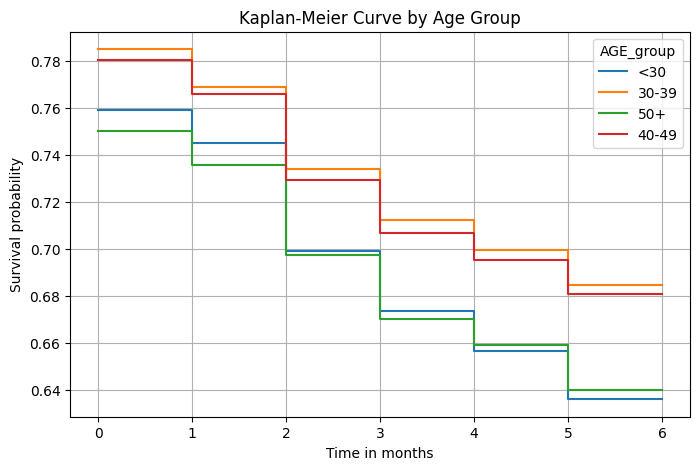


Log-rank test for AGE_group
p-value: 1.2221730400108465e-14


,Variable,Group,N,Events,Event Rate,Median Survival Time,Survival Probability at 6 Months
0,AGE_group,<30,9618,3499,0.363797,inf,0.636203
1,AGE_group,30-39,11238,3543,0.315270,inf,0.684730
2,AGE_group,50+,2680,965,0.360075,inf,0.639925
3,AGE_group,40-49,6464,2062,0.318998,inf,0.681002


In [20]:
age_summary = km_by_group(
    df,
    "AGE_group",
    "Kaplan-Meier Curve by Age Group"
)

age_summary

In [22]:
from lifelines import CoxPHFitter
time_col = "Time to first delay"
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

df["Delay_Event"] = df[pay_cols].gt(0).any(axis=1).astype(int)

df["SEX_group"] = df["SEX"].map({
    1: "Male",
    2: "Female"
})

df["EDUCATION_group"] = df["EDUCATION"].map({
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Other",
    5: "Unknown",
    6: "Unknown",
    0: "Unknown"
})

df["MARRIAGE_group"] = df["MARRIAGE"].map({
    1: "Married",
    2: "Single",
    3: "Other",
    0: "Unknown"
})

df["LIMIT_BAL_group"] = pd.qcut(
    df["LIMIT_BAL"],
    q=3,
    labels=["Low Limit", "Medium Limit", "High Limit"]
)

df["AGE_group"] = pd.cut(
    df["AGE"],
    bins=[0, 29, 39, 49, np.inf],
    labels=["<30", "30-39", "40-49", "50+"]
)

cox_data = df[
    [
        time_col,
        "Delay_Event",
        "EDUCATION_group",
        "SEX_group",
        "MARRIAGE_group",
        "LIMIT_BAL_group",
        "AGE_group"
    ]
].dropna()

cox_data["EDUCATION_group"] = pd.Categorical(
    cox_data["EDUCATION_group"],
    categories=["Graduate School", "University", "High School", "Other", "Unknown"]
)

cox_data["SEX_group"] = pd.Categorical(
    cox_data["SEX_group"],
    categories=["Female", "Male"]
)

cox_data["MARRIAGE_group"] = pd.Categorical(
    cox_data["MARRIAGE_group"],
    categories=["Single", "Married", "Other", "Unknown"]
)

cox_data["LIMIT_BAL_group"] = pd.Categorical(
    cox_data["LIMIT_BAL_group"],
    categories=["High Limit", "Medium Limit", "Low Limit"]
)

cox_data["AGE_group"] = pd.Categorical(
    cox_data["AGE_group"],
    categories=["30-39", "40-49", "<30", "50+"]
)

cox_encoded = pd.get_dummies(
    cox_data,
    columns=[
        "EDUCATION_group",
        "SEX_group",
        "MARRIAGE_group",
        "LIMIT_BAL_group",
        "AGE_group"
    ],
    drop_first=True
)

cph = CoxPHFitter()
cph.fit(
    cox_encoded,
    duration_col=time_col,
    event_col="Delay_Event"
)
print(cph.summary)

                                  coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                                     
EDUCATION_group_University   -0.021253   0.978971  0.023622       -0.067550   
EDUCATION_group_High School   0.019677   1.019872  0.031333       -0.041735   
EDUCATION_group_Other        -0.658962   0.517388  0.224379       -1.098736   
EDUCATION_group_Unknown      -0.840299   0.431581  0.134951       -1.104797   
SEX_group_Male                0.064313   1.066426  0.020488        0.024158   
MARRIAGE_group_Married        0.102636   1.108088  0.023203        0.057159   
MARRIAGE_group_Other         -0.030600   0.969864  0.093962       -0.214762   
MARRIAGE_group_Unknown       -0.031665   0.968831  0.236981       -0.496140   
LIMIT_BAL_group_Medium Limit  0.490858   1.633718  0.028812        0.434388   
LIMIT_BAL_group_Low Limit     0.909656   2.483468  0.028104        0.854574   
AGE_group_40-49              -0.072584   0.929987  0

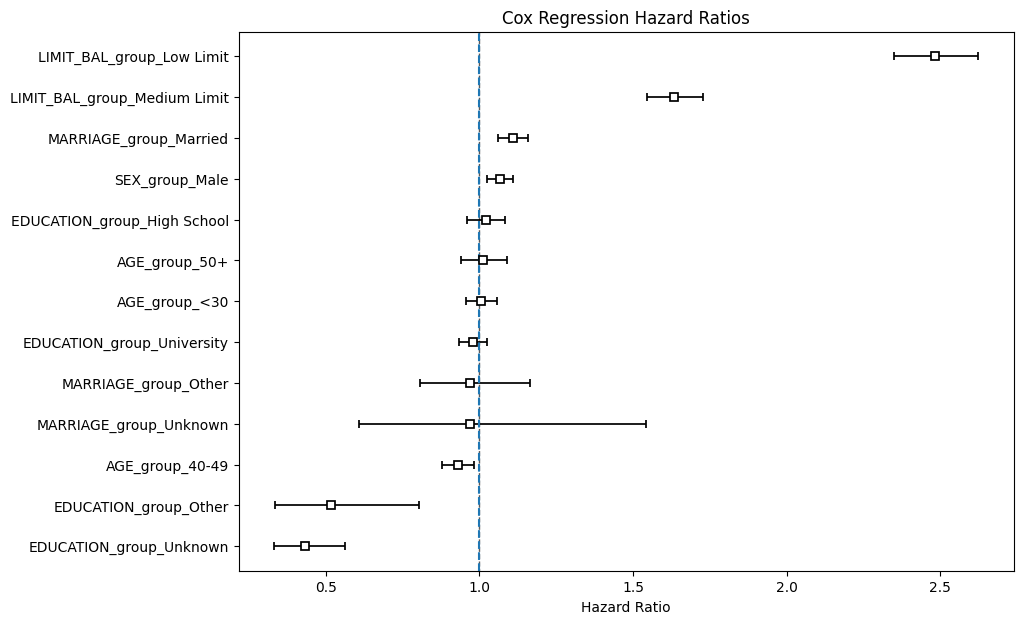

In [23]:
plt.figure(figsize=(10, 7))
cph.plot(hazard_ratios=True)
plt.axvline(x=1, linestyle="--")
plt.title("Cox Regression Hazard Ratios")
plt.xlabel("Hazard Ratio")
plt.show()

<Figure size 800x500 with 0 Axes>

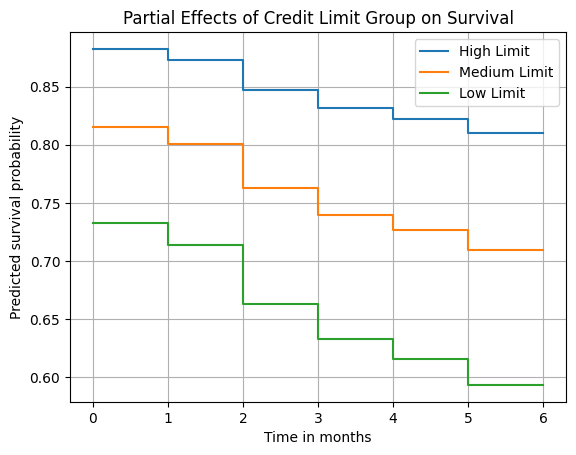

In [24]:
plt.figure(figsize=(8, 5))

ax = cph.plot_partial_effects_on_outcome(
    covariates=[
        "LIMIT_BAL_group_Medium Limit",
        "LIMIT_BAL_group_Low Limit"
    ],
    values=[
        [0, 0],  # High Limit baseline
        [1, 0],  # Medium Limit
        [0, 1]   # Low Limit
    ],
    plot_baseline=False
)

plt.title("Partial Effects of Credit Limit Group on Survival")
plt.xlabel("Time in months")
plt.ylabel("Predicted survival probability")
plt.legend(["High Limit", "Medium Limit", "Low Limit"])
plt.grid(True)
plt.savefig("partial_effect_limit_bal.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 800x500 with 0 Axes>

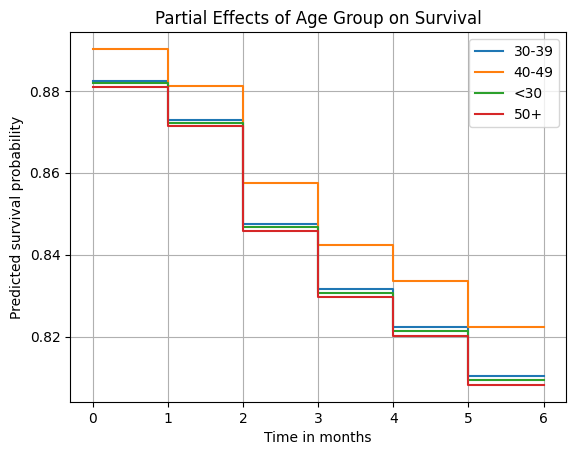

In [25]:
plt.figure(figsize=(8, 5))

ax = cph.plot_partial_effects_on_outcome(
    covariates=[
        "AGE_group_40-49",
        "AGE_group_<30",
        "AGE_group_50+"
    ],
    values=[
        [0, 0, 0],  # 30-39 baseline
        [1, 0, 0],  # 40-49
        [0, 1, 0],  # <30
        [0, 0, 1]   # 50+
    ],
    plot_baseline=False
)

plt.title("Partial Effects of Age Group on Survival")
plt.xlabel("Time in months")
plt.ylabel("Predicted survival probability")
plt.legend(["30-39", "40-49", "<30", "50+"])
plt.grid(True)
plt.savefig("partial_effect_age.png", dpi=300, bbox_inches="tight")
plt.show()